# Section 2: Preprocessing & Feature Engineering

## 1. Introduction
The goal of this section is to transform the raw data into a format that machine learning algorithms can effectively process. While the EDA provided insights into the relationships between health indicators and diabetes risk, we must now handle data inconsistencies, encode categorical variables, and create new features to improve the model's predictive power.

## 2. Objectives
In this phase, we will perform the following tasks:

### **A. Data Cleaning & Refining**
* **Feature Dropping:** Based on the collinearity analysis from the EDA, we will remove `bmi` and `HbA1c_level` to prevent redundancy and improve model stability.
* **Outlier Management:** Identify and handle extreme values in medical indicators (like glucose levels and blood pressure) that could skew the results.

### **B. Feature Engineering**
* **Variable Interaction:** Create new indicators such as the *Health Habits Score*, combining physical activity, sleep quality, and sugar intake.
* **Domain-Driven Thresholds:** Transform continuous variables into meaningful categories where applicable (e.g., classifying waist circumference based on clinical risk thresholds).

### **C. Data Transformation**
* **Encoding:** * **Target Variable:** Map `diabetes_risk_category` into an ordinal numeric scale (0 for Low Risk, 1 for Prediabetes, 2 for High Risk).
* **Categorical Features:** Apply *One-Hot Encoding* to the `gender` variable.
* **Feature Scaling:** Implement `StandardScaler` or `RobustScaler` to normalize the range of independent variables, ensuring that features with larger scales do not dominate the model training.



## 3. Data Splitting
Before applying transformations, we will split the dataset into **Training** and **Testing** sets. This is a critical step to prevent **Data Leakage** and ensure that our evaluation reflects the model's performance on unseen data. We will use a stratified split to maintain the distribution of the risk categories across both sets.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import SMOTE
import sys
import os
from pathlib import Path

In [2]:
# Add project root so "src" can be imported from the notebook
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

# Define the relative path to the file from the project root
data_path = "/Users/josedrube/Documents/Diabetes_Risk_Prediction/Diabetes_Risk_Prediction/src/data/diabetes_risk_dataset.csv"

# Load the dataset
df = pd.read_csv(data_path)
df.head()

,Patient_ID,age,gender,bmi,blood_pressure,fasting_glucose_level,insulin_level,HbA1c_level,cholesterol_level,triglycerides_level,physical_activity_level,daily_calorie_intake,sugar_intake_grams_per_day,sleep_hours,stress_level,family_history_diabetes,waist_circumference_cm,diabetes_risk_score,diabetes_risk_category
0,1,77,Female,33.8,154,93,12.1,5.2,242,194,Low,2169,78.4,8.1,4,No,101.1,52.3,Prediabetes
1,2,54,Male,19.2,123,94,4.6,5.4,212,76,High,1881,16.5,6.6,3,No,60.0,3.7,Low Risk
2,3,25,Male,33.7,141,150,10.8,6.9,247,221,Low,2811,147.9,6.7,10,Yes,114.7,87.3,High Risk
3,4,23,Female,32.8,140,145,11.6,6.8,195,193,Low,2826,98.3,4.4,9,Yes,96.6,76.1,High Risk
4,5,70,Male,33.7,165,90,18.3,5.6,217,170,Moderate,2610,65.8,9.1,5,Yes,107.4,47.7,Prediabetes


## **A. Data Cleaning & Refining**

In [3]:
# Defining a new dataframe to avoid modifying the original one
df_processed = df.copy()

In [4]:
# Target Encoding (Ordinal Mapping)
risk_mapping = {
    'Low Risk': 0,
    'Prediabetes': 1,
    'High Risk': 2
}

# Replacing the diabetes_risk_category with the ordinal mapping
df_processed['diabetes_risk_category'] = df_processed['diabetes_risk_category'].map(risk_mapping)

In [5]:
# Feature Dropping (Based on EDA Collinearity)
features_to_drop = ['Patient_ID', 'bmi', 'HbA1c_level']
df_processed = df_processed.drop(columns=features_to_drop)

print(f"Dataset shape after dropping features: {df_processed.shape}")
df_processed.head()

Dataset shape after dropping features: (6000, 16)


,age,gender,blood_pressure,fasting_glucose_level,insulin_level,cholesterol_level,triglycerides_level,physical_activity_level,daily_calorie_intake,sugar_intake_grams_per_day,sleep_hours,stress_level,family_history_diabetes,waist_circumference_cm,diabetes_risk_score,diabetes_risk_category
0,77,Female,154,93,12.1,242,194,Low,2169,78.4,8.1,4,No,101.1,52.3,1
1,54,Male,123,94,4.6,212,76,High,1881,16.5,6.6,3,No,60.0,3.7,0
2,25,Male,141,150,10.8,247,221,Low,2811,147.9,6.7,10,Yes,114.7,87.3,2
3,23,Female,140,145,11.6,195,193,Low,2826,98.3,4.4,9,Yes,96.6,76.1,2
4,70,Male,165,90,18.3,217,170,Moderate,2610,65.8,9.1,5,Yes,107.4,47.7,1


In [6]:
# Ordinal Encoding for physical_activity_level
# Since "High" is better/more than "Low", we map them in order.
activity_mapping = {
    'Low': 0,
    'Moderate': 1,
    'High': 2
}
df_processed['physical_activity_level'] = df_processed['physical_activity_level'].map(activity_mapping)

# Binary Encoding for family_history_diabetes
# Converting Yes/No into 1/0 is standard practice for binary health history features.
family_history_mapping = {'No': 0, 'Yes': 1}
df_processed['family_history_diabetes'] = df_processed['family_history_diabetes'].map(family_history_mapping)

# One-Hot Encoding for Gender
# Gender is nominal. We use drop_first=True to avoid the 'dummy variable trap'.
# This creates a 'gender_male' column (1 for Male, 0 for Female).
df_processed = pd.get_dummies(df_processed, columns=['gender'], drop_first=True)

# Checking the results
print("Updated Features:")
df_processed.head()

Updated Features:


,age,blood_pressure,fasting_glucose_level,insulin_level,cholesterol_level,triglycerides_level,physical_activity_level,daily_calorie_intake,sugar_intake_grams_per_day,sleep_hours,stress_level,family_history_diabetes,waist_circumference_cm,diabetes_risk_score,diabetes_risk_category,gender_Male
0,77,154,93,12.1,242,194,0,2169,78.4,8.1,4,0,101.1,52.3,1,False
1,54,123,94,4.6,212,76,2,1881,16.5,6.6,3,0,60.0,3.7,0,True
2,25,141,150,10.8,247,221,0,2811,147.9,6.7,10,1,114.7,87.3,2,True
3,23,140,145,11.6,195,193,0,2826,98.3,4.4,9,1,96.6,76.1,2,False
4,70,165,90,18.3,217,170,1,2610,65.8,9.1,5,1,107.4,47.7,1,True


## **B. Feature Engineering & Data Transformation**


In [7]:
# Creating a Health Habits Score
# Normalize the values so they have a similar weight:
# (Activity Level + Sleep) - (Sugar Intake normalized)
# High score = Healthier lifestyle

# Normalize Physical Activity (0-2) -> (0-1)
activity_norm = df_processed['physical_activity_level'] / 2

# Normalize Sleep (4-10) -> (0-1) 
# Formula: (value - min) / (max - min)
sleep_norm = (df_processed['sleep_hours'] - 4) / (10 - 4)

# Normalize Sugar (0-255) -> (0-1)
sugar_norm = df_processed['sugar_intake_grams_per_day'] / 255

# Calculate Score: (Activity + Sleep) - Sugar
df_processed['health_habits_score'] = activity_norm + sleep_norm - sugar_norm
df_processed.head()

,age,blood_pressure,fasting_glucose_level,insulin_level,cholesterol_level,triglycerides_level,physical_activity_level,daily_calorie_intake,sugar_intake_grams_per_day,sleep_hours,stress_level,family_history_diabetes,waist_circumference_cm,diabetes_risk_score,diabetes_risk_category,gender_Male,health_habits_score
0,77,154,93,12.1,242,194,0,2169,78.4,8.1,4,0,101.1,52.3,1,False,0.375882
1,54,123,94,4.6,212,76,2,1881,16.5,6.6,3,0,60.0,3.7,0,True,1.368627
2,25,141,150,10.8,247,221,0,2811,147.9,6.7,10,1,114.7,87.3,2,True,-0.130000
3,23,140,145,11.6,195,193,0,2826,98.3,4.4,9,1,96.6,76.1,2,False,-0.318824
4,70,165,90,18.3,217,170,1,2610,65.8,9.1,5,1,107.4,47.7,1,True,1.091961


In [8]:
# Lipid Ratio
# High triglycerides relative to cholesterol is a strong marker for insulin resistance
df_processed['lipid_ratio'] = df_processed['triglycerides_level'] / df_processed['cholesterol_level']

# High Lipid Risk (Metabolic Risk)
# Marking patients who exceed both clinical thresholds
df_processed['high_lipid_risk'] = ((df_processed['triglycerides_level'] > 150) & (df_processed['cholesterol_level'] > 200)).astype(int)

print("New features added to df_processed.")
df_processed.head()

New features added to df_processed.


,age,blood_pressure,fasting_glucose_level,insulin_level,cholesterol_level,triglycerides_level,physical_activity_level,daily_calorie_intake,sugar_intake_grams_per_day,sleep_hours,stress_level,family_history_diabetes,waist_circumference_cm,diabetes_risk_score,diabetes_risk_category,gender_Male,health_habits_score,lipid_ratio,high_lipid_risk
0,77,154,93,12.1,242,194,0,2169,78.4,8.1,4,0,101.1,52.3,1,False,0.375882,0.801653,1
1,54,123,94,4.6,212,76,2,1881,16.5,6.6,3,0,60.0,3.7,0,True,1.368627,0.358491,0
2,25,141,150,10.8,247,221,0,2811,147.9,6.7,10,1,114.7,87.3,2,True,-0.130000,0.894737,1
3,23,140,145,11.6,195,193,0,2826,98.3,4.4,9,1,96.6,76.1,2,False,-0.318824,0.989744,0
4,70,165,90,18.3,217,170,1,2610,65.8,9.1,5,1,107.4,47.7,1,True,1.091961,0.783410,1


## Correlation Matrix

Checking no redundancy in the new features that were created, all features with a correlation value geater than 95% will be consider collinear.

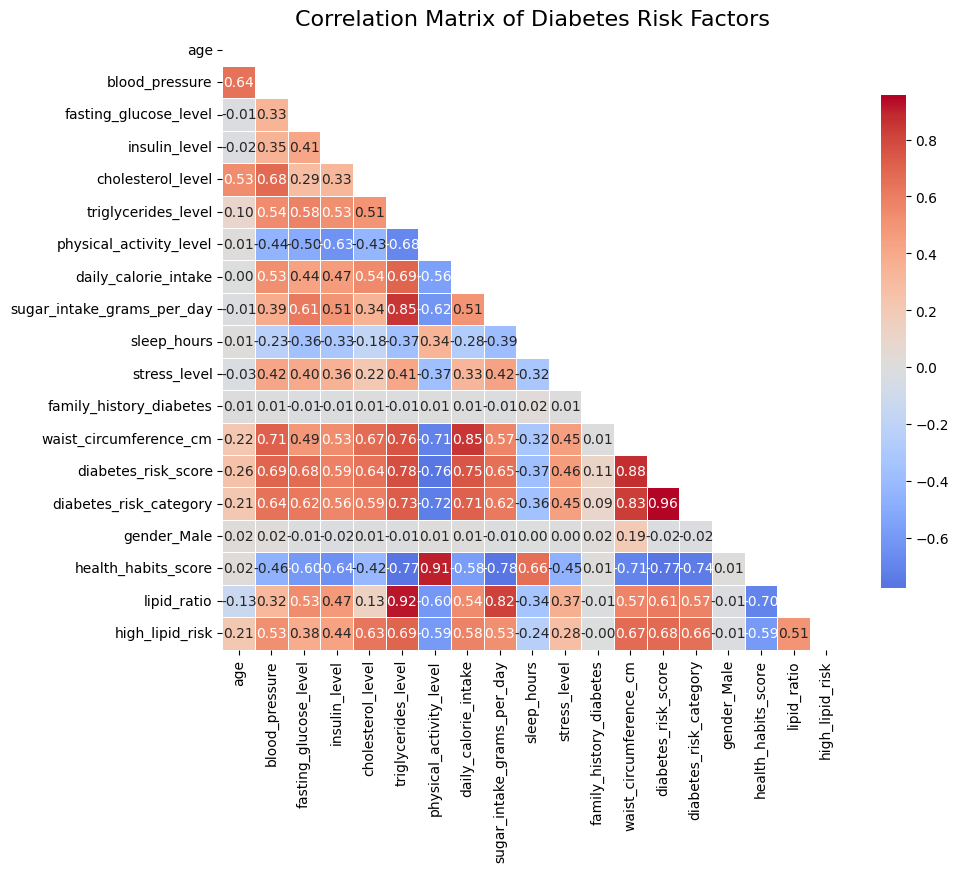

In [9]:
# Calculate the correlation matrix
corr_matrix = df_processed.corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Create a mask to hide the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot the heatmap
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', center=0,linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Diabetes Risk Factors', fontsize=16)
plt.show()

**Observations:** No collinear features (Excluding diabetes_risk_score and diabetes_risk_category)

## Train-Test Split & Scaling

In [10]:
# Defining a new dataframe for the model training
df_model = df_processed.copy()

In [11]:
# Separate Features (X) and Target (y)
X = df_model.drop(columns=['diabetes_risk_category', 'diabetes_risk_score'])
y = df_model['diabetes_risk_category']

# Train-Test Split (Using 80/20 ratio and stratify to keep class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [35]:
# Define the features to scale
# We scale continuous numerical variables, but NOT the binary/categorical ones we already encoded
features_to_scale = ['age', 'blood_pressure', 'fasting_glucose_level', 'insulin_level', 'cholesterol_level',
'triglycerides_level', 'daily_calorie_intake', 'sugar_intake_grams_per_day',
'sleep_hours', 'stress_level', 'waist_circumference_cm', 'health_habits_score', 'lipid_ratio']

scaler = StandardScaler()

# FIT and TRANSFORM the training set
X_train[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])

# ONLY TRANSFORM the test set (using the mean/std from the training set)
X_test[features_to_scale] = scaler.transform(X_test[features_to_scale])

## Addressing Class Imbalance with SMOTE

The target variable `diabetes_risk_category` has three classes (Low Risk, Prediabetes, High Risk) that may be imbalanced. **SMOTE** (Synthetic Minority Over-sampling Technique) generates synthetic samples for minority classes in the training set, improving the model's ability to learn from under-represented categories. We apply SMOTE **only** to the training data after scaling to avoid data leakage; the test set remains unchanged for unbiased evaluation.

In [ ]:
# Class distribution before SMOTE
print("Class distribution (training set, before SMOTE):")
print(y_train.value_counts().sort_index())

# Apply SMOTE only on the training set (after scaling)
# k_neighbors=5 is default; for multi-class SMOTE uses one-vs-rest strategy
smote = SMOTE(random_state=42, k_neighbors=5)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Class distribution after SMOTE
print("\nClass distribution (training set, after SMOTE):")
print(y_train.value_counts().sort_index())
print(f"\nResampled training set shape: X_train {X_train.shape}, y_train {y_train.shape}")

In [36]:
# Create the directory
os.makedirs('../data/processed', exist_ok=True)

# Save files
X_train.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

print("✅ All processed datasets saved in data/processed/")

✅ All processed datasets saved in data/processed/
